# Étape 1 — Collecte, appariement et préparation des données

**Corpus :** Professions de foi des législatives 1993 (Archelec / CEVIPOF)  
**Objectif :** Construire un DataFrame textes + métadonnées, nettoyer les textes,  
lemmatiser et produire une analyse descriptive initiale du corpus.

---
*Fonctions utilitaires centralisées dans `../src/function.py`.*

## 0. Imports

In [3]:
import re
import json
import random
import sys
from pathlib import Path
from io import TextIOWrapper
from zipfile import ZipFile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import spacy
from wordcloud import WordCloud

# Fonctions utilitaires du projet
sys.path.append(str(Path("../src")))
from function import (
    clean_text_for_lda, clean_text_for_embeddings,
    build_lemmatizer, msttr,
    classify_candidate_support, FAMILLES_FINALES,
)

random.seed(45)
np.random.seed(45)

DATA_DIR    = Path("../data")
FIGURES_DIR = Path("../figures")
PROC_DIR    = DATA_DIR / "processed"

ZIP_1993 = DATA_DIR / "legislatives_1993.zip"
META_CSV = DATA_DIR / "meta_archelect_1993.csv"

FIGURES_DIR.mkdir(exist_ok=True)
PROC_DIR.mkdir(exist_ok=True)

print("ZIP :", ZIP_1993.exists(), "| Meta CSV :", META_CSV.exists())

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


ZIP : True | Meta CSV : True


## 1. Chargement des textes

Les fichiers `.txt` sont issus d'une transcription OCR.  
On conserve l'identifiant de chaque document (nom de fichier sans extension)  
pour l'appariement ultérieur avec les métadonnées.

> **Note :** Les fichiers se terminant par `_BV_pdfmasterocr` correspondent  
> à des *bulletins de vote* — hors périmètre, ils sont exclus.

In [4]:
records = {}

with ZipFile(ZIP_1993) as zf:
    for name in zf.namelist():
        if not name.endswith(".txt"):
            continue
        doc_id = Path(name).stem
        if doc_id.endswith("_BV_pdfmasterocr"):
            continue
        with zf.open(name) as f:
            try:
                txt = TextIOWrapper(f, encoding="utf-8", errors="replace").read()
            except Exception:
                f.seek(0)
                txt = TextIOWrapper(f, encoding="latin-1", errors="replace").read()
        records[doc_id] = txt

print(f"{len(records):,} professions de foi chargées")

5,842 professions de foi chargées


## 2. Appariement textes / métadonnées

Le CSV Archelec contient 43 colonnes de métadonnées.  
L'identifiant commun est le champ `id`.

In [5]:
df_meta  = pd.read_csv(META_CSV)
df_texts = pd.DataFrame({"id": list(records.keys()), "raw_text": list(records.values())})

df = df_meta.merge(df_texts, on="id", how="inner")

print(f"Documents après appariement : {len(df):,}")
print(f"Colonnes disponibles        : {len(df.columns)}")
df.head(3)

Documents après appariement : 5,837
Colonnes disponibles        : 43


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,raw_text
0,EL189_L_1993_03_001_01_1_PF_01,1993-03-21,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 50 et 59 ans,gendarme,non mentionné,non mentionné,professionnel,retraité,Front national,non mentionné,non,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...
1,EL189_L_1993_03_001_01_1_PF_02,1993-03-21,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,agent territorial,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
2,EL189_L_1993_03_001_01_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,non mentionné,maire;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,non mentionné,oui,Sciences Po / fonds CEVIPOF\nElections législa...


## 3. Normalisation du soutien partisan

La colonne `titulaire-soutien` contient parfois plusieurs partis séparés par `;`  
(candidatures de coalition). On regroupe chaque candidat dans une **famille  
partisane** unique selon la logique suivante :

| Cas | Résolution |
|-----|-----------|
| Soutien unique | Famille directe |
| Multi-soutien, même famille | Famille commune |
| Famille principale + résidus | Famille principale |
| Plusieurs familles fortes | `Ambigu` (flag) |

In [6]:
codage = df["titulaire-soutien"].apply(classify_candidate_support)
df     = pd.concat([df, codage], axis=1)

# Colonnes lisibles pour export
df["soutiens_liste_str"]   = df["soutiens_liste"].apply(lambda x: " ; ".join(x))
df["familles_detectees_str"] = df["familles_detectees"].apply(lambda x: " ; ".join(x))

# Alias court utilisé dans les analyses
df["titulaire-soutien-simplifie"] = df["famille_partisane"]

print("Distribution par famille partisane :")
print(
    df["titulaire-soutien-simplifie"]
    .value_counts()
    .reindex(FAMILLES_FINALES)
    .dropna()
    .astype(int)
    .to_string()
)

Distribution par famille partisane :
titulaire-soutien-simplifie
Droite parlementaire (RPR/UDF)         1061
Gauche gouvernementale (PS/MRG/MDC)     407
Front national                          651
PCF                                     544
Extrême gauche                          397
Écologistes                            1126
Indépendants / divers                   195
Non mentionné                          1010
Ambigu                                   80
Autres                                  366


## 4. Nettoyage des textes

Deux pipelines parallèles selon l'usage en aval :

- **`clean_text_lda`** — minuscules, sans ponctuation ni chiffres (pour LDA / bag-of-words)  
- **`clean_text_embeddings`** — casse conservée (pour BERTopic / SentenceTransformer)

Les deux pipelines suppriment les artefacts OCR propres au corpus Archelec  
(en-têtes `Sciences Po / fonds CEVIPOF`, mentions d'imprimerie, etc.).

In [7]:
df["clean_text_lda"]        = df["raw_text"].apply(clean_text_for_lda)
df["clean_text_embeddings"] = df["raw_text"].apply(clean_text_for_embeddings)

df["n_chars_raw"]           = df["raw_text"].str.len()
df["n_words_lda"]           = df["clean_text_lda"].str.split().str.len()
df["n_words_emb"]           = df["clean_text_embeddings"].str.split().str.len()

print(df[["n_chars_raw", "n_words_lda", "n_words_emb"]].describe().round(1))

       n_chars_raw  n_words_lda  n_words_emb
count       5837.0       5837.0       5837.0
mean        4163.2        656.3        656.3
std         2065.8        337.2        337.2
min          168.0         15.0         15.0
25%         2525.0        392.0        392.0
50%         3898.0        607.0        607.0
75%         5431.0        865.0        865.0
max        20160.0       3306.0       3306.0


### 4.1 Exclusion des documents trop courts

On retire les documents dont le texte nettoyé contient moins de **50 mots**  
— ils correspondent à des fichiers OCR quasi-vides ou des formulaires non renseignés.

In [8]:
print(f"Documents < 50 mots : {(df['n_words_lda'] < 50).sum()}")
display(df[df["n_words_lda"] < 50][["id", "n_words_lda", "raw_text"]])

df_clean = df[df["n_words_lda"] >= 50].reset_index(drop=True)
print(f"\nCorpus final : {len(df_clean):,} documents")

Documents < 50 mots : 2


,id,n_words_lda,raw_text
1621,EL191_L_1993_03_040_01_1_PF_06,15,LEGISLATIVES DU. 21 MARS 1993\nCANDIDAT LIBRE ...
3029,EL194_L_1993_03_068_06_1_PF_01,36,La commission de propagande électorale a décid...



Corpus final : 5,835 documents


## 5. Lemmatisation avec spaCy

On utilise le modèle français `fr_core_news_md`.  
Le pipeline exclut les stop-words (liste spaCy + liste personnalisée du corpus  
électoral : artefacts OCR, formules d'adresse, vocabulaire administratif),  
la ponctuation et les tokens de moins de 3 caractères.

> ⏱ Cette cellule prend ~2–3 minutes sur le corpus complet (5 835 docs).

In [9]:
try:
    nlp = spacy.load("fr_core_news_md")
    print("Modèle fr_core_news_md chargé")
except OSError:
    nlp = spacy.load("fr_core_news_sm")
    print("Modèle fr_core_news_sm chargé (md non disponible)")

lemmatize = build_lemmatizer(nlp)

df_clean["tokens"] = [
    lemmatize(text) for text in df_clean["clean_text_lda"]
]
df_clean["n_tokens"] = df_clean["tokens"].str.len()

print(f"Tokens moyens par document : {df_clean['n_tokens'].mean():.0f}")
print(f"Tokens médians             : {df_clean['n_tokens'].median():.0f}")

Modèle fr_core_news_md chargé
Tokens moyens par document : 310
Tokens médians             : 290


## 6. Analyse descriptive

### 6.1 Nuages de mots

Trois niveaux d'analyse : corpus global, par famille partisane (top 6), par sexe.

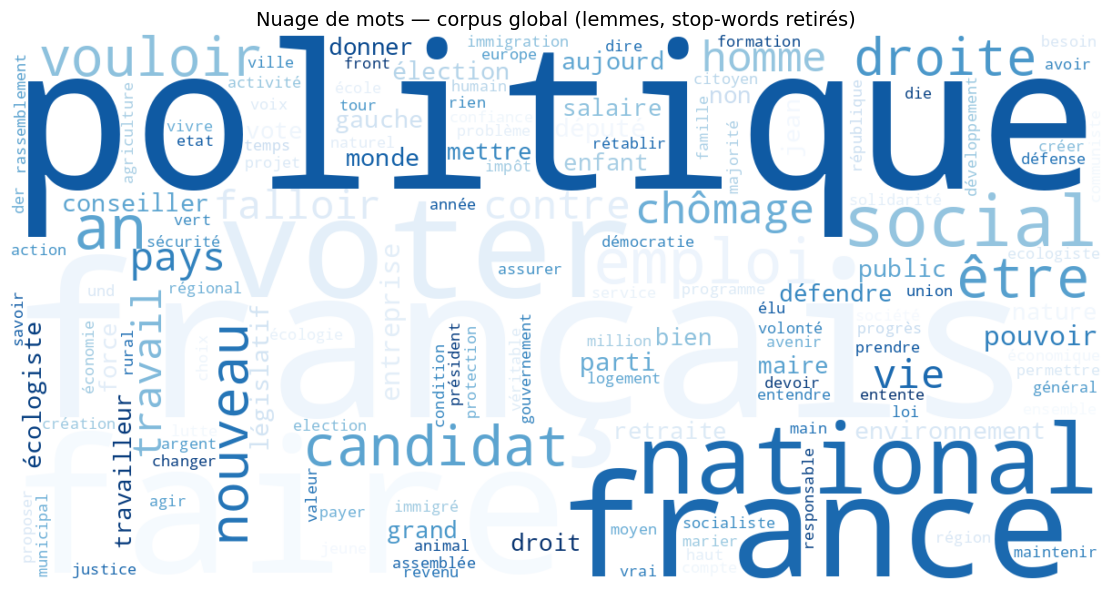

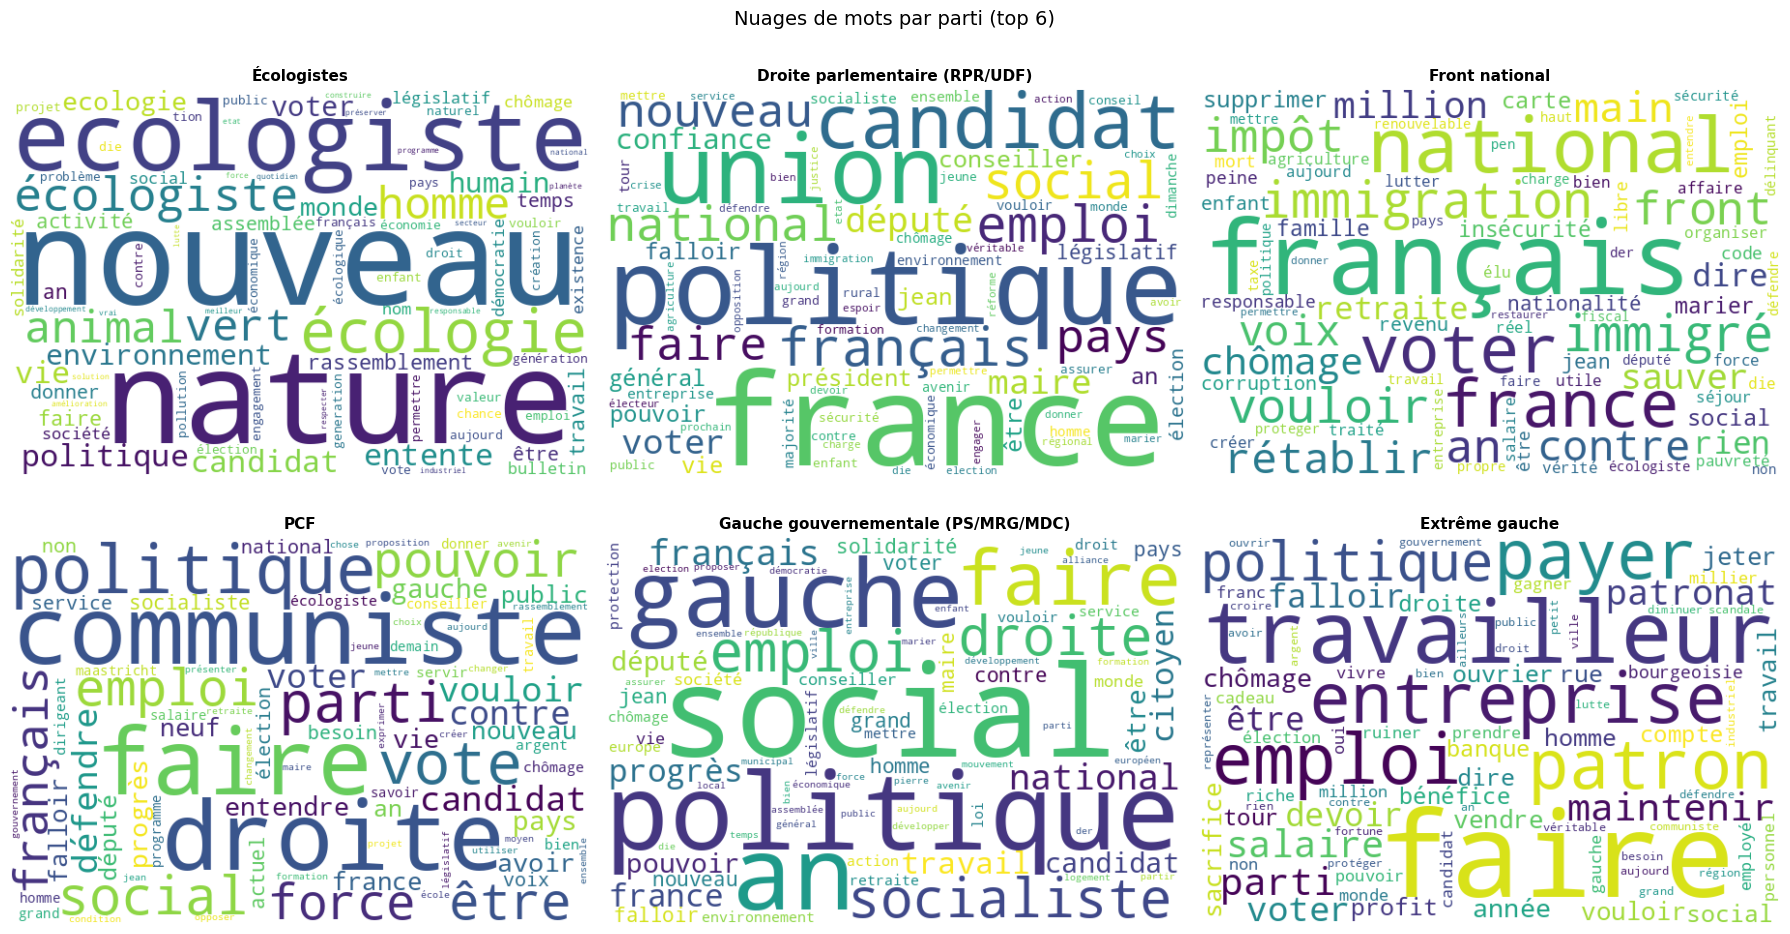

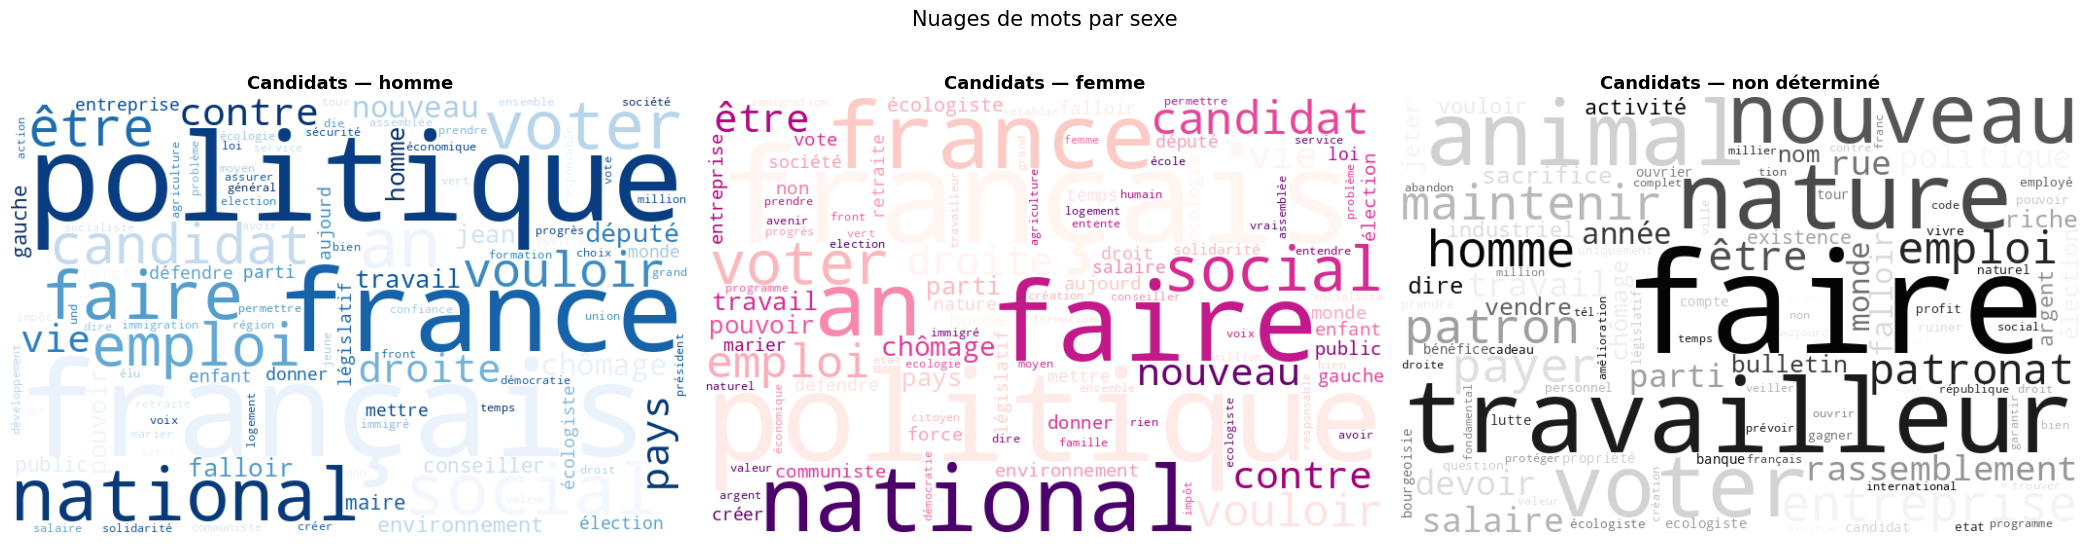

In [10]:
all_tokens  = [t for toks in df_clean["tokens"] for t in toks]
freq_global = Counter(all_tokens)

# ── Global ──
wc_global = WordCloud(
    width=1200, height=600, background_color="white",
    colormap="Blues", max_words=150, collocations=False
).generate_from_frequencies(freq_global)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_global, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuage de mots — corpus global (lemmes, stop-words retirés)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_wordcloud_global.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Par parti (top 6) ──
top6_partis = [
    p for p in df_clean["titulaire-soutien-simplifie"].value_counts().index
    if p not in ("Non mentionné", "Ambigu", "Autres", "Indépendants / divers")
][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, parti in zip(axes.flatten(), top6_partis):
    tokens_p = [t for toks in df_clean[df_clean["titulaire-soutien-simplifie"] == parti]["tokens"] for t in toks]
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=80, collocations=False
                   ).generate_from_frequencies(Counter(tokens_p))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(parti, fontsize=11, fontweight="bold")
plt.suptitle("Nuages de mots par parti (top 6)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_wordcloud_partis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Par sexe ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (sexe, cmap) in zip(axes, [("homme","Blues"), ("femme","RdPu"), ("non déterminé","Greys")]):
    tokens_s = [t for toks in df_clean[df_clean["titulaire-sexe"] == sexe]["tokens"] for t in toks]
    if not tokens_s:
        ax.text(0.5, 0.5, "Données insuffisantes", ha="center", va="center")
        ax.axis("off"); ax.set_title(f"Candidats — {sexe}", fontsize=13); continue
    wc = WordCloud(width=700, height=450, background_color="white",
                   colormap=cmap, max_words=100, collocations=False
                   ).generate_from_frequencies(Counter(tokens_s))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(f"Candidats — {sexe}", fontsize=13, fontweight="bold")
plt.suptitle("Nuages de mots par sexe", fontsize=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_wordcloud_genre.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Distribution par parti

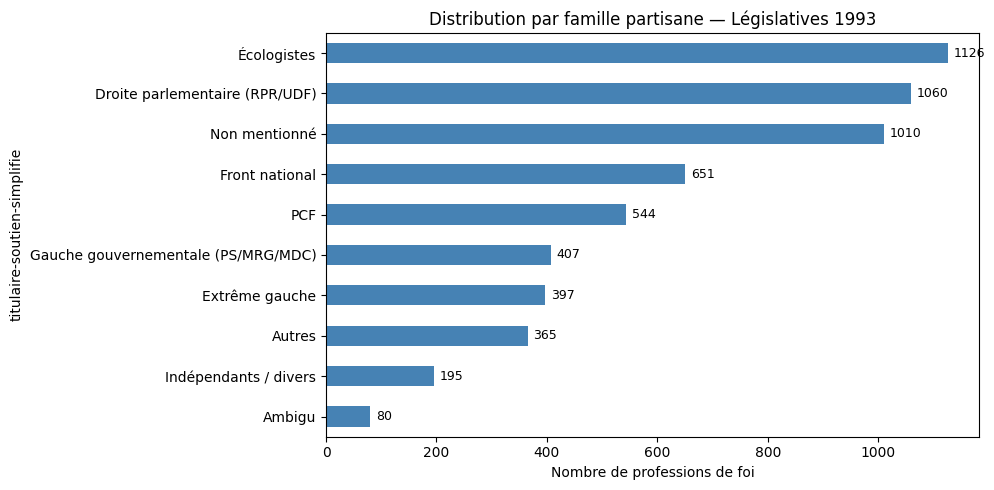

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_clean["titulaire-soutien-simplifie"].value_counts().sort_values()
counts.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Nombre de professions de foi")
ax.set_title("Distribution par famille partisane — Législatives 1993")
for i, v in enumerate(counts):
    ax.text(v + 10, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_dist_partis.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Répartition par sexe

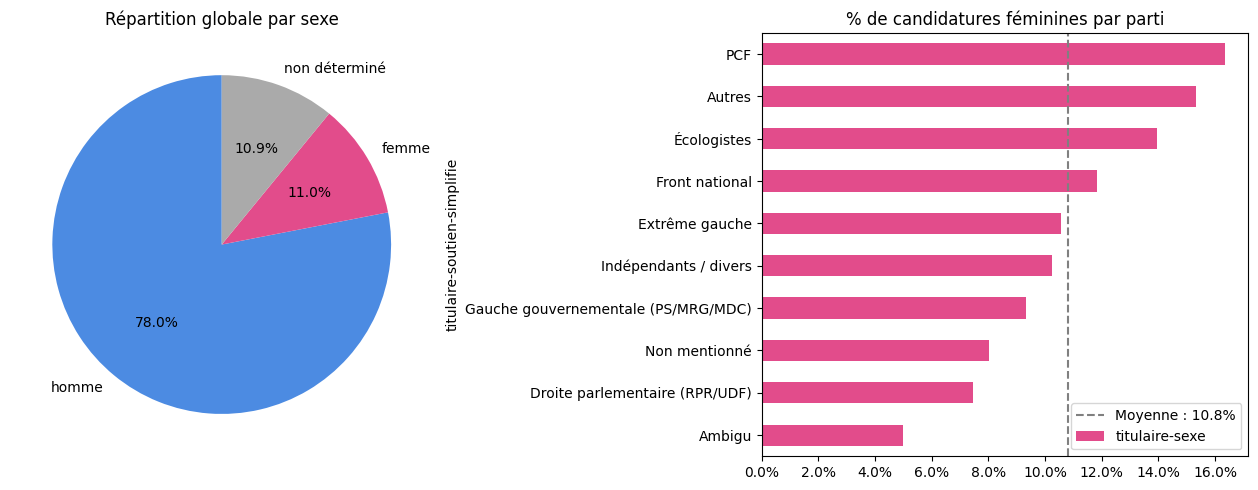

titulaire-sexe
homme            4554
femme             643
non déterminé     638


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Camembert global
sexe_counts = df_clean["titulaire-sexe"].value_counts()
sexe_counts.plot.pie(
    ax=axes[0], autopct="%1.1f%%", startangle=90,
    colors=["#4C8BE2", "#E24C8B", "#AAAAAA"]
)
axes[0].set_title("Répartition globale par sexe"); axes[0].set_ylabel("")

# % femmes par parti
pct_femmes = (
    df_clean.groupby("titulaire-soutien-simplifie")["titulaire-sexe"]
    .apply(lambda s: (s == "femme").mean() * 100)
    .sort_values()
)
pct_femmes.plot.barh(ax=axes[1], color="#E24C8B")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("% de candidatures féminines par parti")
axes[1].axvline(pct_femmes.mean(), color="gray", linestyle="--",
                label=f"Moyenne : {pct_femmes.mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_dist_sexe.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats de base
print(df_clean["titulaire-sexe"].value_counts().to_string())

### 6.4 Distribution de la longueur des textes

On observe la distribution du nombre de mots après nettoyage,  
ainsi que les différences de longueur entre partis.

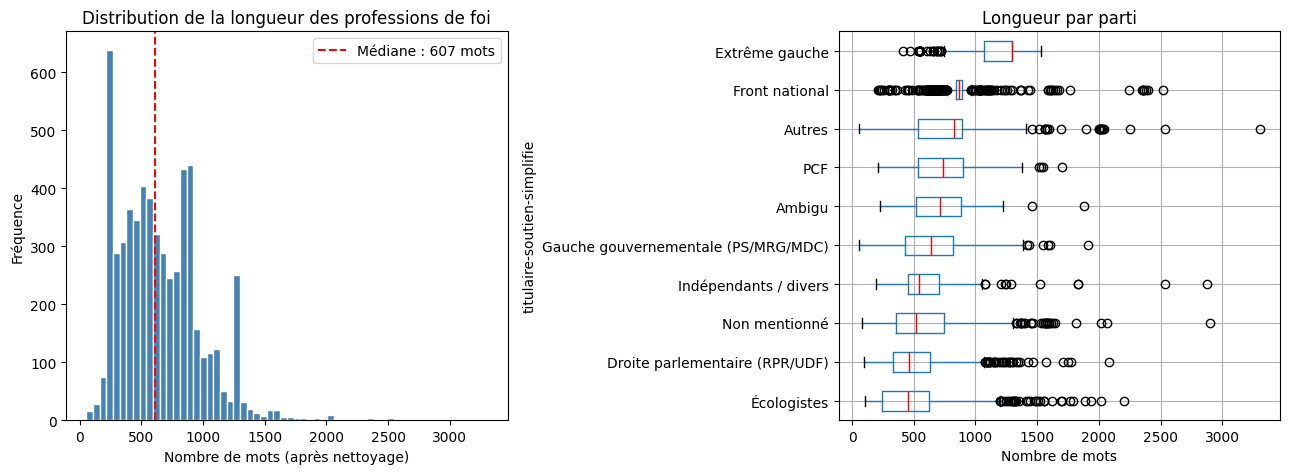

       n_words_lda  n_tokens
count       5835.0    5835.0
mean         656.5     309.5
std          337.0     166.6
min           53.0      24.0
25%          392.0     181.0
50%          607.0     290.0
75%          865.0     404.0
max         3306.0    1716.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
med = df_clean["n_words_lda"].median()
axes[0].hist(df_clean["n_words_lda"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Nombre de mots (après nettoyage)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution de la longueur des professions de foi")
axes[0].axvline(med, color="red", linestyle="--", label=f"Médiane : {med:.0f} mots")
axes[0].legend()

# Boxplot par parti
order = (df_clean.groupby("titulaire-soutien-simplifie")["n_words_lda"]
         .median().sort_values().index.tolist())
df_clean["titulaire-soutien-simplifie"] = pd.Categorical(
    df_clean["titulaire-soutien-simplifie"], categories=order, ordered=True
)
df_clean.boxplot(
    column="n_words_lda", by="titulaire-soutien-simplifie",
    ax=axes[1], vert=False, medianprops=dict(color="red")
)
axes[1].set_title("Longueur par parti"); axes[1].set_xlabel("Nombre de mots")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_longueur_textes.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean[["n_words_lda", "n_tokens"]].describe().round(1))

### 6.5 Richesse lexicale (MSTTR)

Le **Mean Segmental TTR** (MSTTR) mesure la diversité du vocabulaire  
sur des fenêtres fixes de 100 tokens — ce qui neutralise l'effet de la longueur  
du texte, contrairement au TTR brut.

In [14]:
df_clean["msttr"] = df_clean["tokens"].apply(msttr)

print("MSTTR moyen par parti (trié décroissant) :")
print(
    df_clean.groupby("titulaire-soutien-simplifie")["msttr"]
    .mean().sort_values(ascending=False).round(3).to_string()
)

MSTTR moyen par parti (trié décroissant) :
titulaire-soutien-simplifie
Écologistes                            0.883
PCF                                    0.862
Gauche gouvernementale (PS/MRG/MDC)    0.861
Indépendants / divers                  0.860
Non mentionné                          0.859
Ambigu                                 0.858
Front national                         0.854
Autres                                 0.853
Droite parlementaire (RPR/UDF)         0.849
Extrême gauche                         0.825


/tmp/ipykernel_2478/4184352612.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby("titulaire-soutien-simplifie")["msttr"]


### 6.6 Heatmap — top 30 lemmes par parti

La heatmap représente la fréquence relative (pour mille) des 30 lemmes  
les plus fréquents du corpus global, ventilée par famille partisane.

/tmp/ipykernel_2478/3222601566.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for parti, grp in df_clean.groupby("titulaire-soutien-simplifie"):


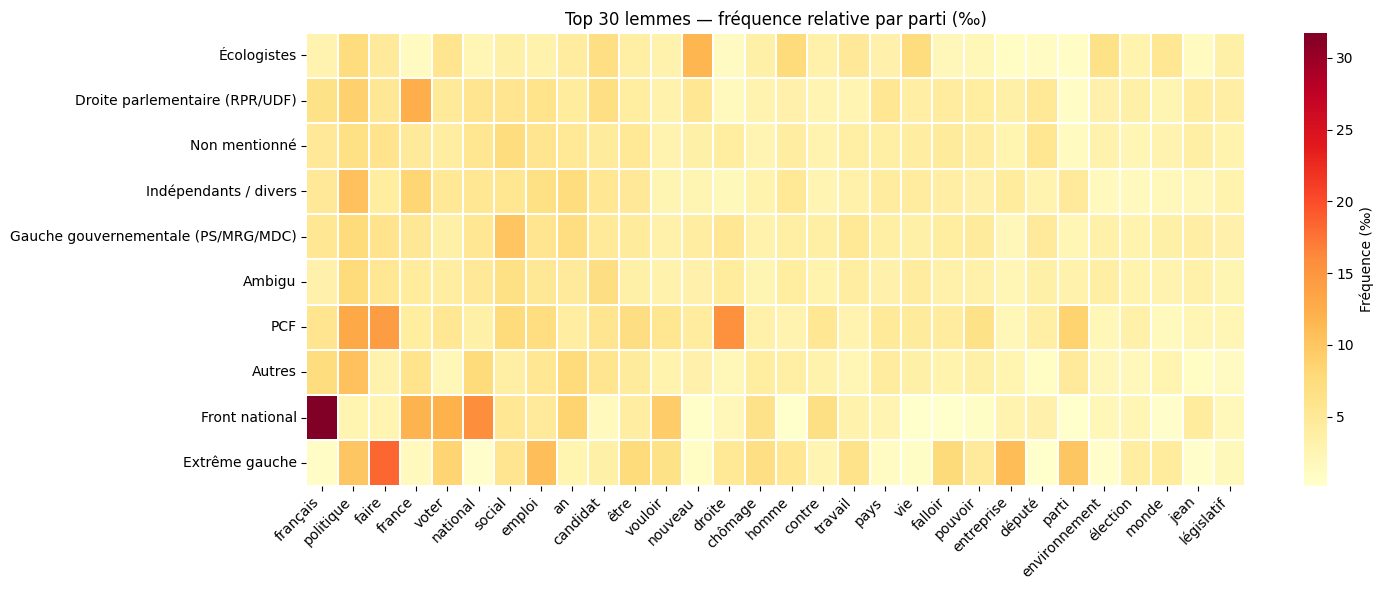


Taille du vocabulaire total : 50,509 lemmes uniques
Tokens totaux               : 1,806,002


In [15]:
vocab     = Counter(all_tokens)
top_words = [w for w, _ in vocab.most_common(30)]

heatmap_data = {}
for parti, grp in df_clean.groupby("titulaire-soutien-simplifie"):
    parti_tokens = [t for toks in grp["tokens"] for t in toks]
    total = len(parti_tokens)
    if total == 0:
        continue
    c = Counter(parti_tokens)
    heatmap_data[parti] = {w: c.get(w, 0) / total * 1000 for w in top_words}

df_heatmap = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(df_heatmap, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Fréquence (‰)"})
ax.set_title("Top 30 lemmes — fréquence relative par parti (‰)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_heatmap_vocab.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTaille du vocabulaire total : {len(vocab):,} lemmes uniques")
print(f"Tokens totaux               : {len(all_tokens):,}")

## 7. Sauvegarde

On exporte deux fichiers :
- **`corpus_1993.csv`** — DataFrame principal avec métadonnées, textes nettoyés et métriques
- **`tokens_1993.jsonl`** — Tokens lemmatisés (un document par ligne, format JSON Lines)

In [16]:
COLS_EXPORT = [
    "id",
    "titulaire-sexe", "titulaire-profession",
    "titulaire-soutien", "titulaire-soutien-simplifie", "famille_partisane",
    "departement-nom", "contexte-tour",
    "raw_text", "clean_text_lda", "clean_text_embeddings",
    "n_chars_raw", "n_words_lda", "n_tokens", "msttr",
]

df_clean[COLS_EXPORT].to_csv(PROC_DIR / "corpus_1993.csv", index=False)
print("✓ Sauvegardé :", PROC_DIR / "corpus_1993.csv")

with open(PROC_DIR / "tokens_1993.jsonl", "w", encoding="utf-8") as f:
    for row in df_clean[["id", "tokens"]].itertuples():
        f.write(json.dumps({"id": row.id, "tokens": row.tokens}, ensure_ascii=False) + "\n")
print("✓ Sauvegardé :", PROC_DIR / "tokens_1993.jsonl")

✓ Sauvegardé : ../data/processed/corpus_1993.csv
✓ Sauvegardé : ../data/processed/tokens_1993.jsonl


In [17]:
print("=" * 50)
print("RÉSUMÉ DU CORPUS — Législatives 1993")
print("=" * 50)
print(f"Documents total            : {len(df_clean):,}")
print(f"  dont hommes              : {(df_clean['titulaire-sexe']=='homme').sum():,}")
print(f"  dont femmes              : {(df_clean['titulaire-sexe']=='femme').sum():,}")
print(f"  dont non déterminé       : {(df_clean['titulaire-sexe']=='non déterminé').sum():,}")
print(f"Familles partisanes        : {df_clean['titulaire-soutien-simplifie'].nunique()}")
print(f"Tokens moyens / document   : {df_clean['n_tokens'].mean():.0f}")
print(f"Taille du vocabulaire      : {len(vocab):,} lemmes uniques")
print(f"Figures générées           : {FIGURES_DIR}")
print(f"Données exportées          : {PROC_DIR}")

RÉSUMÉ DU CORPUS — Législatives 1993
Documents total            : 5,835
  dont hommes              : 4,554
  dont femmes              : 643
  dont non déterminé       : 638
Familles partisanes        : 10
Tokens moyens / document   : 310
Taille du vocabulaire      : 50,509 lemmes uniques
Figures générées           : ../figures
Données exportées          : ../data/processed
